In [1]:
from csv import DictReader

with open('properties_master.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    rows = [r for r in reader]
csv_file.close()

compounds = []
for r in rows:
    if r['properties.flash_point.value'] != '-':
        compounds.append(r)

In [2]:
from sklearn.model_selection import train_test_split

smiles = [c['canonical_smiles'] for c in compounds]
targets = [[float(c['properties.flash_point.value'])] for c in compounds]

smiles_train, smiles_test, targets_train, targets_test = train_test_split(
    smiles, targets, test_size=0.2, random_state=24
)

In [3]:
from ecnet.datasets import QSPRDataset

ds_train = QSPRDataset(smiles_train, targets_train, backend='alvadesc')
ds_test = QSPRDataset(smiles_test, targets_test, backend='alvadesc')

In [4]:
from ecnet import ECNet

net = ECNet(ds_train.desc_vals.shape[1], ds_train.target_vals.shape[1], 128, 1)
loss_train, loss_valid = net.fit(
    dataset=ds_train,
    batch_size=32,
    epochs=512,
    valid_size=0.25,
    random_state=24,
    patience=64,
    verbose=10
)

Epoch: 0 | Train loss: 3139.6499262791053 | Valid loss: 9223372036854775807
Epoch: 10 | Train loss: 723.3968254538144 | Valid loss: 828.4990234375
Epoch: 20 | Train loss: 307.3447852041207 | Valid loss: 536.6781616210938
Epoch: 30 | Train loss: 258.3613833757787 | Valid loss: 420.4117736816406
Epoch: 40 | Train loss: 172.04298510582618 | Valid loss: 398.37542724609375
Epoch: 50 | Train loss: 160.104319055096 | Valid loss: 373.26220703125
Epoch: 60 | Train loss: 165.68762012556488 | Valid loss: 407.54608154296875
Epoch: 70 | Train loss: 111.48374609853707 | Valid loss: 340.26849365234375
Epoch: 80 | Train loss: 141.11322589949066 | Valid loss: 336.5707702636719
Epoch: 90 | Train loss: 100.81868359933492 | Valid loss: 429.0613098144531
Epoch: 100 | Train loss: 79.61811718909568 | Valid loss: 334.193115234375
Epoch: 110 | Train loss: 73.70336871676975 | Valid loss: 314.48870849609375
Epoch: 120 | Train loss: 68.13753783780766 | Valid loss: 313.43658447265625
Epoch: 130 | Train loss: 69.35

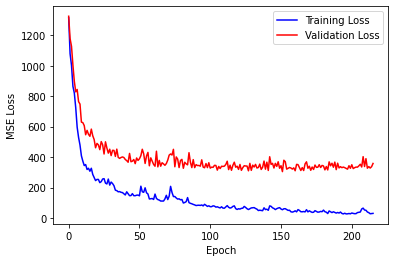

In [5]:
from matplotlib import pyplot as plt

loss_train = loss_train[5:]
loss_valid = loss_valid[5:]
epochs = [i for i in range(len(loss_train))]

plt.clf()
plt.plot(epochs, loss_train, label='Training Loss', color='blue')
plt.plot(epochs, loss_valid, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend(loc='upper right')
plt.show()

In [6]:
from sklearn.metrics import median_absolute_error, r2_score

results_train = net.forward(ds_train.desc_vals).detach().numpy()
targets_train = ds_train.target_vals.detach().numpy()
results_test = net.forward(ds_test.desc_vals).detach().numpy()
targets_test = ds_test.target_vals.detach().numpy()

mae_train = median_absolute_error(targets_train, results_train)
mae_test = median_absolute_error(targets_test, results_test)
r2_train = r2_score(targets_train, results_train)
r2_test = r2_score(targets_test, results_test)

print(f'Train: {mae_train}, {r2_train}')
print(f'Test: {mae_test}, {r2_test}')

Train: 3.614274024963379, 0.9628506776520601
Test: 6.713432312011719, 0.9209160712741915


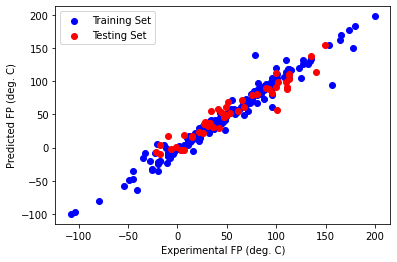

In [7]:
plt.clf()

plt.scatter(targets_train, results_train, label='Training Set', color='blue')
plt.scatter(targets_test, results_test, label='Testing Set', color='red')
plt.legend(loc='upper left')
plt.xlabel('Experimental FP (deg. C)')
plt.ylabel('Predicted FP (deg. C)')
plt.show()